# Which junctions extra reads add

Among the junctions detected in all 100 subsamples of the four heart (DCM)
samples, does the mix of gene and junction properties change as sequencing
depth goes from 50M to 300M mapped reads? For each feature the proportional
representation of every sub-category is regressed against depth, and the two
most divergent sub-categories are compared with a two-tailed z-test on the
difference between their slopes.

Both inputs are built by `scripts/summarise_junction_features.py` from the
junction feature table: the counts per depth and sub-category, and a matrix of
how strongly the features are associated with each other.

Compactness is the summed length of a gene's exons over its total length. A
gene counts as fast-evolving if it overlaps a human accelerated region, and as
heart-specific if it is on the heart-elevated gene list. The pair of
sub-categories compared for each feature is the pair whose slopes differ most,
chosen after fitting, so the p-value is optimistic even after the
Benjamini-Hochberg step across the eight features.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import false_discovery_control

# Locate the top of the clone, so the notebook runs from any directory inside it.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "asdepth").is_dir()), None)
if ROOT is None:
    raise RuntimeError("run this from inside a clone of RNA-Seq_Depth_for_AS")

DERIVED = ROOT / "data" / "derived"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

CONTINUOUS = ["PSI", "GC_content", "Compactness", "TPM"]
CATEGORICAL = ["Gene_type", "Region", "Is_heart_specific", "Is_fast_evolving"]
FEATURES = CONTINUOUS + CATEGORICAL

# Slopes are reported per 10M reads.
SCALE = 10

COLORS = {
    "TPM": "#0047AB",
    "Gene_type": "#C0392B",
    "Compactness": "#1A7A2E",
    "Region": "#E07B00",
    "PSI": "#6A0DAD",
    "Is_fast_evolving": "#008B8B",
    "Is_heart_specific": "#C2185B",
    "GC_content": "#7B3F00",
}

## Counts per depth and sub-category

Continuous features are split into tertiles, categorical ones into their
classes. The proportions below are taken over every sub-category, including
the rarer classes that the figure leaves out.

In [2]:
counts = pd.read_csv(DERIVED / "feature_counts.tsv", sep="\t")
print(f"{counts['count'].sum():,} junction observations, "
      f"depths {sorted(counts['depth'].unique())}")
counts.head()

25,498,321 junction observations, depths [50, 100, 150, 200, 250, 300]


,feature,depth,subcategory,count
0,PSI,50,Low,127451
1,PSI,50,Medium,118352
2,PSI,50,High,129272
3,PSI,100,Low,162003
4,PSI,100,Medium,151180


## Proportional slopes

In [3]:
def subcategories_of(rows, continuous):
    """Sub-categories to plot: the tertiles, or the three most frequent classes.

    The proportions are taken over every sub-category, including the rarer
    classes that are left out of the figure.
    """
    if continuous:
        return ["Low", "Medium", "High"]
    totals = rows.groupby("subcategory")["count"].sum()
    return totals.sort_values(ascending=False).head(3).index.tolist()


def proportional_slopes(counts, feature, continuous):
    """Slope of each sub-category's proportion against sequencing depth."""
    rows = counts[counts["feature"] == feature]
    totals = rows.groupby("depth")["count"].sum()

    slopes = {}
    for name in subcategories_of(rows, continuous):
        series = rows[rows["subcategory"] == name]
        if len(series) < 3:
            continue
        depth = series["depth"].to_numpy()
        proportion = series["count"].to_numpy() / totals[depth].to_numpy()
        fit = stats.linregress(depth, proportion)
        slopes[name] = {"slope": fit.slope, "std_err": fit.stderr}
    return slopes


def compare_extremes(slopes, continuous):
    """Two-tailed z-test on the difference between the two extreme slopes."""
    if continuous:
        high, low = slopes["High"], slopes["Low"]
    else:
        high = max(slopes.values(), key=lambda s: s["slope"])
        low = min(slopes.values(), key=lambda s: s["slope"])
    difference = high["slope"] - low["slope"]
    combined = np.sqrt(high["std_err"] ** 2 + low["std_err"] ** 2)
    z = difference / combined if combined > 0 else 0.0
    return 2 * (1 - stats.norm.cdf(abs(z)))


trends = {}
for feature in FEATURES:
    continuous = feature in CONTINUOUS
    slopes = proportional_slopes(counts, feature, continuous)
    trends[feature] = {
        "slopes": slopes,
        "p_value": compare_extremes(slopes, continuous),
    }

# Benjamini-Hochberg across the eight features.
features = list(trends)
fdr = false_discovery_control([trends[f]["p_value"] for f in features], method="bh")
for feature, value in zip(features, fdr):
    trends[feature]["fdr"] = value

ranked = sorted(
    features,
    key=lambda f: max(abs(s["slope"]) for s in trends[f]["slopes"].values()),
    reverse=True,
)

pd.DataFrame(
    [
        {
            "feature": f,
            "max |slope| per 10M": max(
                abs(s["slope"]) for s in trends[f]["slopes"].values()) * SCALE,
            "p": trends[f]["p_value"],
            "FDR": trends[f]["fdr"],
        }
        for f in ranked
    ]
).round(6)

,feature,max |slope| per 10M,p,FDR
0,TPM,0.005120,0.000000,0.000000
1,PSI,0.001440,0.997648,0.997648
2,Gene_type,0.001432,0.000000,0.000000
3,Compactness,0.001287,0.000000,0.000000
4,Region,0.000795,0.000000,0.000000
5,Is_fast_evolving,0.000319,0.000000,0.000000
6,Is_heart_specific,0.000061,0.000000,0.000000
7,GC_content,0.000003,0.991367,0.997648


## Effect size against significance

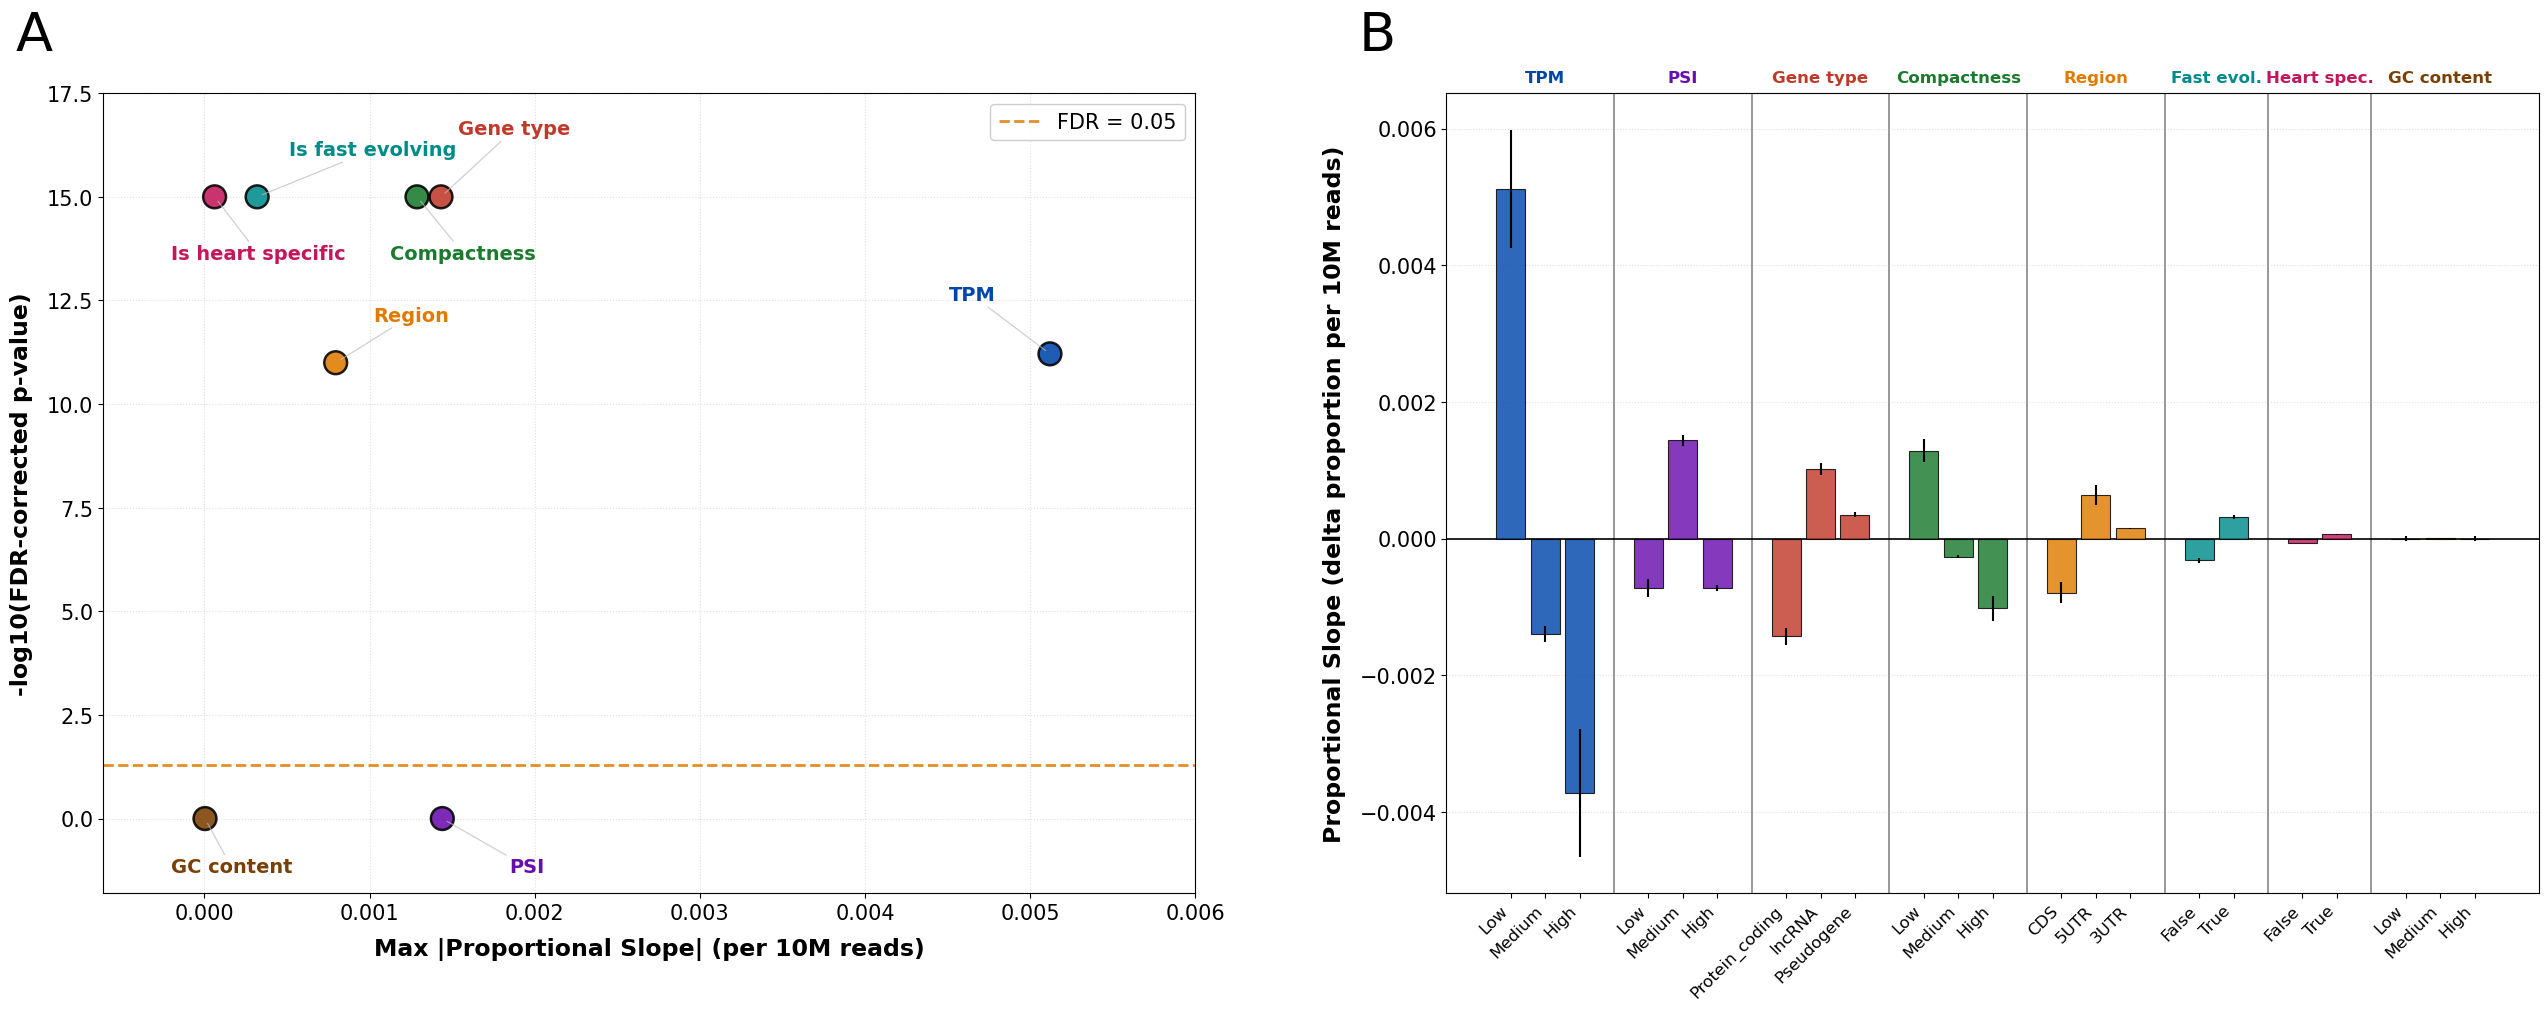

In [4]:
# Where to put each feature's label: x as a fraction of the widest slope,
# y in data units. The points cluster, so the labels are placed by hand.
LABEL_POSITIONS = {
    "TPM": (0.88, 12.5),
    "PSI": (0.36, -1.3),
    "Gene_type": (0.30, 16.5),
    "Compactness": (0.22, 13.5),
    "Region": (0.20, 12.0),
    "Is_fast_evolving": (0.10, 16.0),
    "Is_heart_specific": (-0.04, 13.5),
    "GC_content": (-0.04, -1.3),
}

figure = plt.figure(figsize=(27, 10))
left, right, top = 0.07, 0.96, 0.90
width = (right - left) / 2.2
gap = 0.23 * width
volcano = figure.add_axes([left, 0.10, width, top - 0.10])
bars = figure.add_axes([left + width + gap, 0.10, width, top - 0.10])

# Volcano: effect size against significance, one point per feature.
x = [max(abs(s["slope"]) for s in trends[f]["slopes"].values()) * SCALE
     for f in ranked]
# An FDR of exactly 0 has underflowed; 15 is past the largest finite value here.
y = [-np.log10(trends[f]["fdr"]) if trends[f]["fdr"] > 0 else 15 for f in ranked]

volcano.scatter(x, y, c=[COLORS[f] for f in ranked], s=270, alpha=0.88,
                edgecolors="black", linewidth=1.8, zorder=3)
volcano.axhline(-np.log10(0.05), color="#E07B00", ls="--", lw=2, alpha=0.85,
                label="FDR = 0.05")
volcano.set_xlim(-max(x) * 0.12, 0.006)
volcano.set_ylim(-1.8, 17.5)

for feature, px, py in zip(ranked, x, y):
    offset_x, offset_y = LABEL_POSITIONS[feature]
    volcano.annotate(
        feature.replace("_", " "),
        xy=(px, py), xytext=(max(x) * offset_x, offset_y), textcoords="data",
        fontsize=14, fontweight="bold", color=COLORS[feature],
        annotation_clip=False,
        arrowprops=dict(arrowstyle="-", color="#BBBBBB", lw=0.9, alpha=0.7,
                        shrinkA=0, shrinkB=4),
        zorder=5,
    )

volcano.set_xlabel("Max |Proportional Slope| (per 10M reads)",
                   fontsize=17, fontweight="bold", labelpad=10)
volcano.set_ylabel("-log10(FDR-corrected p-value)",
                   fontsize=17, fontweight="bold", labelpad=10)
volcano.text(-0.08, 1.04, "A", transform=volcano.transAxes, fontsize=39,
             va="bottom", ha="left")
volcano.legend(loc="upper right", fontsize=15, framealpha=0.95)
volcano.tick_params(labelsize=15)
volcano.grid(alpha=0.40, ls=":", lw=0.8)

# Bars: one bar per sub-category, grouped by feature, ordered as in the volcano.
positions, heights, errors, colors, labels = [], [], [], [], []
groups = []
cursor = 0.0
for feature in ranked:
    start = cursor
    for name, slope in trends[feature]["slopes"].items():
        positions.append(cursor)
        heights.append(slope["slope"] * SCALE)
        errors.append(slope["std_err"] * SCALE)
        colors.append(COLORS[feature])
        labels.append(name)
        cursor += 0.65
    groups.append((feature, start, cursor - 0.65))
    cursor += 0.65

bars.axhline(0, color="black", lw=1.2, zorder=1)
bars.grid(axis="y", alpha=0.40, ls=":", lw=0.8)
bars.set_axisbelow(True)
for (_, _, end), (_, next_start, _) in zip(groups, groups[1:]):
    bars.axvline((end + next_start) / 2, color="#444444", lw=1.4, alpha=0.55, zorder=0)

bars.bar(positions, heights, width=0.55, color=colors, alpha=0.82,
         edgecolor="black", linewidth=0.8, zorder=2)
for position, height, error in zip(positions, heights, errors):
    bars.vlines(position, height - error, height + error, color="black",
                lw=1.5, zorder=3)

bars.set_xticks(positions)
bars.set_xticklabels(labels, rotation=45, ha="right", fontsize=12)
bars.tick_params(axis="y", labelsize=15)
bars.set_ylabel("Proportional Slope (delta proportion per 10M reads)",
                fontsize=17, fontweight="bold", labelpad=10)
bars.text(-0.08, 1.04, "B", transform=bars.transAxes, fontsize=39,
          va="bottom", ha="left")

SHORT = {"Is_fast_evolving": "Fast evol.", "Is_heart_specific": "Heart spec.",
         "GC_content": "GC content", "Gene_type": "Gene type"}

for feature, start, end in groups:
    bars.text((start + end) / 2, 1.01, SHORT.get(feature, feature),
              transform=bars.get_xaxis_transform(), ha="center", va="bottom",
              fontsize=12, fontweight="bold", color=COLORS[feature])

figure.savefig(RESULTS / "Figure_4.png", dpi=300, bbox_inches="tight")
figure.savefig(RESULTS / "Figure_4.svg", format="svg", bbox_inches="tight")
plt.show()

## How the features relate to each other

The association measure depends on the pair of variable types: signed Pearson
or point-biserial r for continuous and boolean pairs, the correlation ratio
for continuous against nominal, and Cramer's V for nominal pairs. Unsigned
measures are marked with an asterisk. The matrix is taken at the deepest
sequencing depth.

In [5]:
DISPLAY = {
    "log_TPM": "TPM", "PSI": "PSI", "PSI_ext": "|0.5 − PSI|",
    "Gene_type": "Gene type", "Compactness": "Compactness", "Region": "Region",
    "Is_fast_evolving": "Is fast evolving",
    "Is_heart_specific": "Is heart specific", "GC_content": "GC content",
}
PANEL = list(DISPLAY)
DEPTH = max(counts["depth"])

matrix = pd.read_csv(DERIVED / "feature_associations.tsv", sep="\t",
                     index_col=0).to_numpy()
signed = pd.read_csv(DERIVED / "feature_associations_signed.tsv", sep="\t",
                     index_col=0).to_numpy()
annotations = (
    pd.read_csv(DERIVED / "feature_associations_labels.tsv", sep="\t", index_col=0)
    .fillna("").to_numpy()
)
size = len(PANEL)

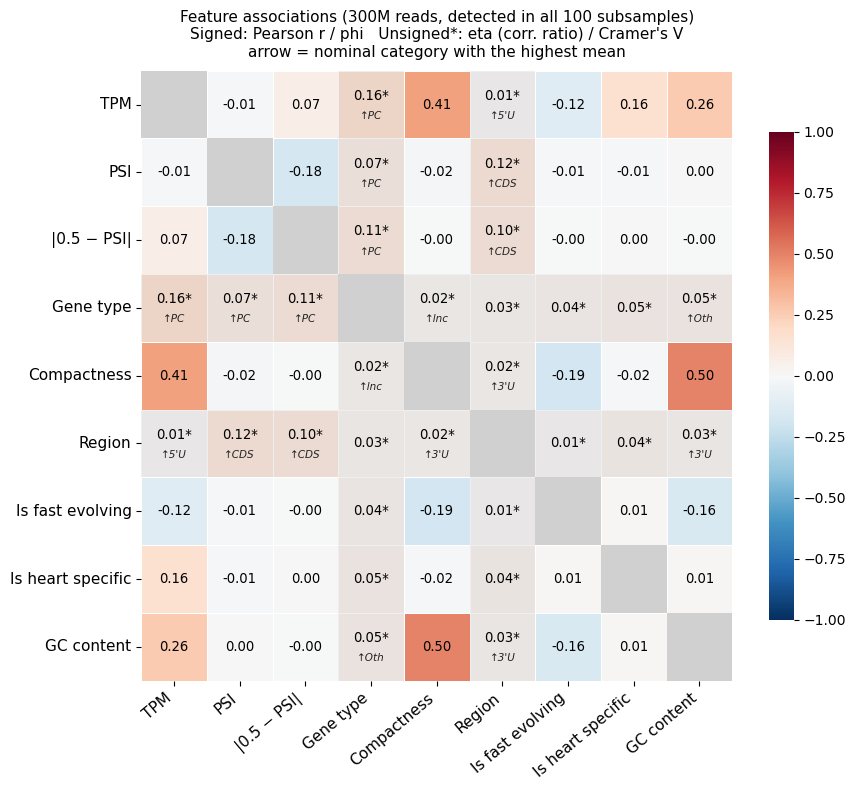

In [6]:
labels = [DISPLAY[f] for f in PANEL]
figure, axes = plt.subplots(figsize=(9, 8))

sns.heatmap(
    pd.DataFrame(matrix, index=labels, columns=labels),
    cmap="RdBu_r", vmin=-1, vmax=1, center=0, ax=axes,
    mask=np.eye(size, dtype=bool), linewidths=0.5, linecolor="white",
    annot=False, cbar_kws={"shrink": 0.8},
)

for i in range(size):
    axes.add_patch(plt.Rectangle((i, i), 1, 1, color="#d0d0d0", lw=0, zorder=2))
    for j in range(size):
        if i != j and not signed[i, j]:
            axes.add_patch(plt.Rectangle((j, i), 1, 1, color="#888888",
                                         alpha=0.13, lw=0, zorder=2))

for i in range(size):
    for j in range(size):
        if i == j:
            continue
        value = matrix[i, j]
        color = "white" if abs(value) > 0.55 else "black"
        text = f"{value:.2f}" + ("" if signed[i, j] else "*")
        if annotations[i, j]:
            axes.text(j + 0.5, i + 0.37, text, ha="center", va="center",
                      fontsize=9.5, color=color, zorder=3)
            axes.text(j + 0.5, i + 0.67, f"↑{annotations[i, j]}",
                      ha="center", va="center", fontsize=7.5, color="#222222",
                      style="italic", zorder=3)
        else:
            axes.text(j + 0.5, i + 0.5, text, ha="center", va="center",
                      fontsize=9.5, color=color, zorder=3)

axes.set_title(
    f"Feature associations ({DEPTH}M reads, detected in all 100 subsamples)\n"
    "Signed: Pearson r / phi   Unsigned*: eta (corr. ratio) / Cramer's V\n"
    "arrow = nominal category with the highest mean",
    fontsize=11, pad=10,
)
axes.tick_params(labelsize=11)
plt.setp(axes.get_xticklabels(), rotation=40, ha="right")
plt.setp(axes.get_yticklabels(), rotation=0)
figure.tight_layout()
figure.savefig(RESULTS / "Figure_S4.png", dpi=300, bbox_inches="tight")
plt.show()